# RobotReview
Product review aggregator 

## 1. Imports and Setup

In [1]:
import sys
!{sys.executable} -m pip install kagglehub
!{sys.executable} -m pip install pandas numpy scikit-learn transformers openai
!{sys.executable} -m pip install wordcloud

In [2]:
import pandas as pd
import numpy as np
import os
import warnings
import kagglehub
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from transformers import pipeline
import openai

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

### Download dataset

In [3]:
# Download latest version
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products", output_dir='./data')

print("Path to dataset files:", path)

Path to dataset files: ./data


## 2. Data preprocessing

In [4]:
df1 = pd.read_csv("data/1429_1.csv")
df2 = pd.read_csv("data/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv")
df3 = pd.read_csv("data/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv")

# Merge the 3 files in a single DataFrame
df_all = pd.concat([df1, df2, df3], ignore_index=True)

# Cleaning : duplicates and missing values
df_clean = df_all.dropna(subset=['reviews.text', 'reviews.rating', 'name'])
# Duplicates : when review text is the same
df_clean = df_clean.drop_duplicates(subset=['reviews.text'])

# Keep only relevant columns
df_clean = df_clean[['name', 'reviews.title', 'reviews.text', 'reviews.rating', 'categories']]

# Function to map stars (1-5) to sentiment (Negative, Neutral, Positive)
def map_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df_clean['rating_sentiment'] = df_clean['reviews.rating'].apply(map_sentiment)

print(f"Dataset merged and cleaned: {df_clean.shape} reviews")
display(df_clean)

Dataset merged and cleaned: (40924, 6) reviews


,name,reviews.title,reviews.text,reviews.rating,categories,rating_sentiment
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Kindle,This product so far has not disappointed. My c...,5.0,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Positive
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",very fast,great for beginner or experienced person. Boug...,5.0,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Positive
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...,5.0,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Positive
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Good!!!,I've had my Fire HD 8 two weeks now and I love...,4.0,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Positive
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Fantastic Tablet for kids,I bought this for my grand daughter when she c...,5.0,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Positive
...,...,...,...,...,...,...
66331,"Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...",Outstanding,Very nice people and good product. I would buy...,5.0,"eBook Readers,Fire Tablets,Electronics Feature...",Positive
66332,"Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...","good tablet, nice size",Easy to set up. Good size tablet. Like the add...,5.0,"eBook Readers,Fire Tablets,Electronics Feature...",Positive
66336,"Amazon - Kindle Voyage - 6"" - 4GB - Black",Loved the device but not the price,"I have an old Kindle Touch, the last one that ...",4.0,"eBook Readers,Electronics Features,Walmart for...",Positive
66398,"Amazon - Kindle Voyage - 6"" - 4GB - Black",Great product,This is my third one of these and this is the ...,5.0,"eBook Readers,Electronics Features,Walmart for...",Positive


## 3. Classification Sentiment Analysis Model
Using Hugging Face pipeline
> Execution time : 40min on my computer with DistilBert

> Execution time : 6min with Roberta on Google Colab

In [ ]:
# Load text classification model
sentiment_classifier = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment")

# Small sample
df_sample = df_clean.copy()

def predict_sentiment(text):
    if not isinstance(text, str):
        return 'Neutral'

    # Truncate to 512 characters to prevent token limit crashes (RoBERTa limit is 512 tokens).
    truncated_text = text[:512]

    try:
        result = sentiment_classifier(truncated_text)[0]
        label = result['label']

        # Map RoBERTa specific labels to our custom sentiment classes
        if label == 'LABEL_0':
            return 'Negative'
        elif label == 'LABEL_1':
            return 'Neutral'
        elif label == 'LABEL_2':
            return 'Positive'
        else:
            return 'Neutral'
    except Exception as e:
        # Fallback in case of pipeline errors
        return 'Neutral'

df_sample['predicted_sentiment'] = df_sample['reviews.text'].apply(predict_sentiment)
print("Classification completed!")

### Saving DataFrame

In [ ]:
# Save the dataframe with predictions to a new CSV file
# df_sample.to_csv("data/processed_reviews_with_sentiment.csv", index=False)

# print("Data successfully saved to data/processed_reviews_with_sentiment.csv")

Data successfully saved to data/processed_reviews_with_sentiment.csv


### Loading dataframe

In [6]:
# Load the previously saved dataframe to skip the model execution
import pandas as pd

file_path = "data/processed_reviews_with_sentiment.csv"

df_sample = pd.read_csv(file_path)
print("Pre-computed data loaded successfully! Shape:", df_sample.shape)

Pre-computed data loaded successfully! Shape: (40924, 7)


In [7]:
# display(df_clean["rating_sentiment"].head(200).value_counts())
display(df_sample["rating_sentiment"].value_counts())
display(df_sample["predicted_sentiment"].value_counts())

rating_sentiment
Positive    37321
Neutral      1882
Negative     1721
Name: count, dtype: int64

predicted_sentiment
Positive    35492
Neutral      2878
Negative     2554
Name: count, dtype: int64

## 4. Product Category Clustering
TF-IDF & K-Means

In [8]:
def clean_noisy_keywords(text):
    # Removes the word 'Amazon' (case-insensitive) to prevent it from dominating the TF-IDF matrix
    if not isinstance(text, str):
        return ""
    # Remove 'Amazon' regardless of case
    cleaned_text = re.sub(r'(?i)\bamazon\b', '', text)
    return cleaned_text.strip()

def apply_hardcoded_rules(name):
    # Forcefully labels specific products based on keywords
    if not isinstance(name, str):
        return None
    if re.search(r'(?i)adapter|cable', name):
        return 'Accessories'
    return None

# Create the new cleaned feature
df_sample['rich_text_clean'] = (df_sample['name'].fillna('') + " " + df_sample['categories'].fillna('')).apply(clean_noisy_keywords)

# Apply rule-based overrides
# df_sample['hardcoded_category'] = df_sample['name'].apply(apply_hardcoded_rules)

# Isolate the rows that need algorithmic clustering (those NOT hardcoded)
# mask_needs_clustering = df_sample['hardcoded_category'].isnull()
# df_to_cluster = df_sample[mask_needs_clustering].copy()

# print(f"Rows forcefully labeled as 'Accessories': {len(df_sample[~mask_needs_clustering])}")
# print(f"Rows passed to KMeans clustering: {len(df_to_cluster)}")

In [10]:
# Combine
# df_sample['combined_text'] = (df_sample['name'].fillna('') + " " +
#                           df_sample['reviews.title'].fillna('') + " " +
#                           df_sample['reviews.text'].fillna(''))
df_sample['combined_text'] = (df_sample['name'].fillna('') + " " + df_sample['categories'].fillna(''))


# Transform words into numerical data (Vectorization TF-IDF)
vectorizer = TfidfVectorizer(stop_words='english', max_features=1500, ngram_range=(1, 3))
X_features = vectorizer.fit_transform(df_sample['combined_text'])

# Apply K-Means to group products into 5 Meta-categories
kmeans = KMeans(n_clusters=5, random_state=42)
df_sample['meta_category'] = kmeans.fit_predict(X_features)

print("Clustering complete. Distribution of meta-categories:")
print(df_sample['meta_category'].value_counts())

Clustering complete. Distribution of meta-categories:
meta_category
2    10755
1     8845
3     7932
4     6841
0     6551
Name: count, dtype: int64



Generating WordClouds to visualize Cluster Topics...


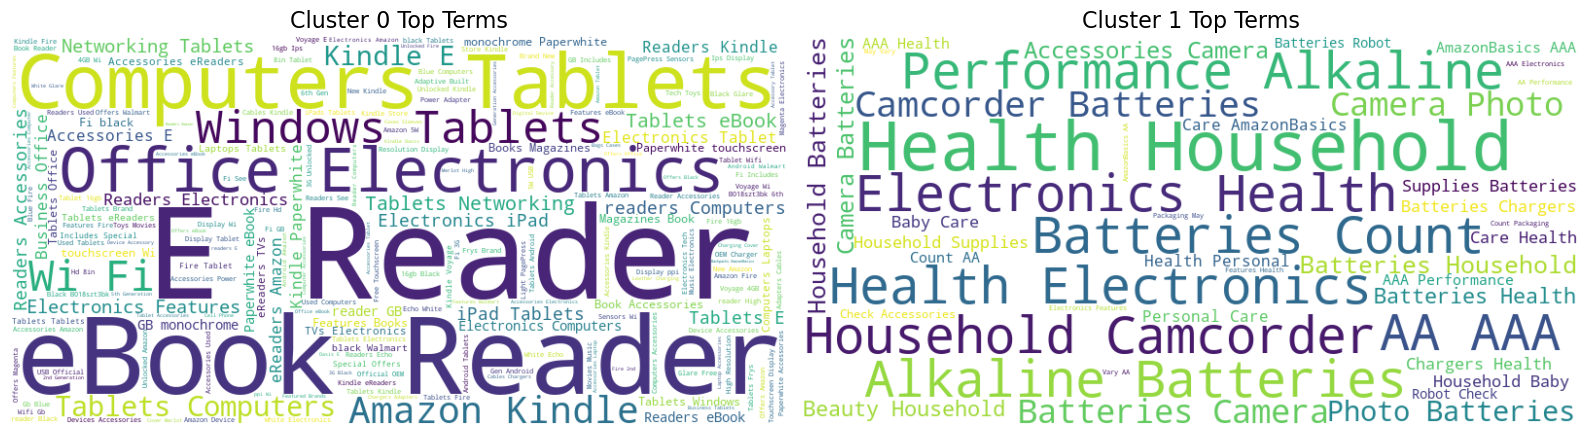

In [11]:
print("\nGenerating WordClouds to visualize Cluster Topics...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i in range(2):
    cluster_text = " ".join(df_sample[df_sample['meta_category'] == i]['combined_text'].tolist())
    if cluster_text.strip():
        wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(cluster_text)
        axes[i].imshow(wordcloud, interpolation='bilinear')
        axes[i].set_title(f'Cluster {i} Top Terms', fontsize=16)
    else:
        axes[i].set_title(f'Cluster {i} (Empty)')
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# 5. Ranking products
Extracting the best and worst products + common complaints for a given meta-category

In [12]:
def rank_products_in_category(df, category_id):
    # Filter for the chosen cluster category
    cat_df = df[df['meta_category'] == category_id].copy()

    sentiment_map = {'Positive': 1, 'Neutral': 0, 'Negative': -1}
    cat_df['sentiment_score'] = cat_df['predicted_sentiment'].map(sentiment_map)

    # Group by product name to aggregate statistics
    product_stats = cat_df.groupby('name').agg(
        review_count=('reviews.text', 'count'),
        avg_score=('sentiment_score', 'mean'),
        complaints=('reviews.text', lambda x: list(x[cat_df.loc[x.index, 'predicted_sentiment'] == 'Negative'])[:3])
    ).reset_index()

    # if product_stats.empty:
    #     return None

    # Sort products by highest average score, breaking ties with the highest review count
    ranked_products = product_stats.sort_values(by=['avg_score', 'review_count'], ascending=[False, False])

    # 1. Top 3 best products
    top_3_products = ranked_products.head(3)['name'].tolist()

    # 2. The worst product (lowest score)
    worst_product = ranked_products.tail(1)['name'].values[0]

    # 3. Flatten the lists of complaints into a single sample list
    all_complaints = []
    for complaints in ranked_products['complaints']:
        all_complaints.extend(complaints)

    # Keep up to 5 complaints total to avoid overwhelming the LLM prompt later
    sample_complaints = all_complaints[:5]

    num_products = len(ranked_products)

    return {
        'top_3': top_3_products,
        'worst': worst_product,
        'complaints': sample_complaints,
        'unique_products_count': num_products
    }

# Test the ranking function on cluster
target_category = 0
ranking_results = None
if 'meta_category' in df_sample.columns:
    ranking_results = rank_products_in_category(df_sample, target_category)

if ranking_results and len(ranking_results['top_3']) > 0:
    print(f"--- Results for Meta-Category {target_category} ---")
    print(f"Unique products found in this cluster: {ranking_results['unique_products_count']}")
    print(f"Top 3 Best Products: {ranking_results['top_3']}")
    print(f"Worst Product to Avoid: {ranking_results['worst']}")
    print(f"Sample Complaints: {len(ranking_results['complaints'])} found.")
    print(f"Sample Complaints: {ranking_results['complaints']} ")
else:
    print(f"Not enough data to rank category {target_category}.")

--- Results for Meta-Category 0 ---
Unique products found in this cluster: 57
Top 3 Best Products: ['Expanding Accordion File Folder Plastic Portable Document Organizer Letter Size', 'Kindle Paperwhite,,,\r\nKindle Paperwhite,,,', 'Amazon Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Blue Kid-Proof Case - Blue']
Worst Product to Avoid: Oem Amazon Kindle Power Usb Adapter Wall Travel Charger Fire/dx/+micro Usb Cable
Sample Complaints: 5 found.
Sample Complaints: ['My Kindle Voyage is nearly 16 months old and worked perfectly. I kept receiving emails from Amazon about the software update. I switched off airplane mode, switched on wifi and shortly after the screen locked up. I have tried everything with customer support and they now tell me I will have to buy a new one. I am very annoyed. If I had left the software as it was my Kindle Voyage would still be working.', 'My first kindle paperwhite lasted several years, and I used it a lot! When it quit, I immediately went to Best Buy an

# 6. Review Summarization

In [13]:
# Load OPENAPI KEY from .env file
import os
from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv())

openai.api_key  = os.getenv('OPENAI_API_KEY')

In [14]:
def generate_blog_post(category_data):
    """
    Constructs a prompt using ranked product data and calls OpenAI to generate a blog post.
    """
    if not category_data:
        return "Insufficient data to generate a blog post."

    # Format the data for the prompt
    top_3_str = ", ".join(category_data['top_3'])
    worst_product = category_data['worst']

    # Clean and truncate complaints so the prompt doesn't exceed token limits
    complaints_str = "\n- ".join([str(c)[:150] + "..." for c in category_data['complaints']])
    if not complaints_str:
        complaints_str = "No major complaints found in this sample."

    # Construct the LLM Prompt
    prompt = f"""
    Act as an expert tech reviewer writing a short, engaging blog post about a specific product category.

    Here is the data you need to include in your post:
    - Top 3 Best Products: {top_3_str}
    - The Worst Product (DO NOT BUY): {worst_product}
    - Common user complaints in this category:
    - {complaints_str}

    Please follow these STRICT INSTRUCTIONS:
    1. Write an article of approximately 300 to 400 words.
    2. Never make up or hallucinate product names. Use exactly what is provided.
    3. Structure the review strictly as follows:
    
    Paragraph 1: Introduce the category and compare the Top 3 products based on when a consumer should choose one over the other.
    
    Paragraph 2: Highlight the main complaints or cons provided in the data.
    
    Paragraph 3: Clearly identify the worst product ({worst_product}) and explain why users should absolutely avoid buying it based on the general category flaws
    
    Final Paragraph: You are now allowed to be highly creative, natural, and humorous to wrap up the article and say goodbye to the reader.

    Keep the tone professional yet accessible.
    """

    try:
        client = openai.OpenAI(api_key=openai.api_key)
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "You are a strict, factual tech reviewer who loves a funny sign-off."},
                # {"role": "system", "content": "You are an expert tech reviewer."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.7,
            max_tokens=600
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"API Error: {e}"

# Use the real data if it exists, otherwise fall back to dummy data to verify the GenAI pipeline
blog_post = generate_blog_post(ranking_results)

print("\n--- FINAL GENERATED BLOG POST ---")
print(blog_post)


--- FINAL GENERATED BLOG POST ---
### The Best Portable Document Organizers and E-Readers: A Review of Your Options

When it comes to organizing your life or diving into the world of books, the right tools can make all the difference. In the realm of portable document organizers and e-readers, three standout products to consider are the Expanding Accordion File Folder Plastic Portable Document Organizer, the Kindle Paperwhite, and the Amazon Fire Kids Edition Tablet. If you’re looking for a way to keep your papers in check, the Expanding Accordion File Folder is your best bet, offering ample space and portability for documents. However, if you’re a book lover, the Kindle Paperwhite is a wise investment for an immersive reading experience. Meanwhile, the Amazon Fire Kids Edition Tablet is perfect for parents seeking a kid-friendly device that combines entertainment and education. 

Despite their strengths, these products aren’t without their flaws, and user complaints paint a mixed pic

# Evaluation of the Sentiment Model
Generating metrics and visualizations to evaluate model performance

              precision    recall  f1-score   support

    Negative       0.49      0.73      0.59      1721
     Neutral       0.15      0.22      0.18      1882
    Positive       0.97      0.92      0.95     37321

    accuracy                           0.88     40924
   macro avg       0.54      0.63      0.57     40924
weighted avg       0.91      0.88      0.90     40924



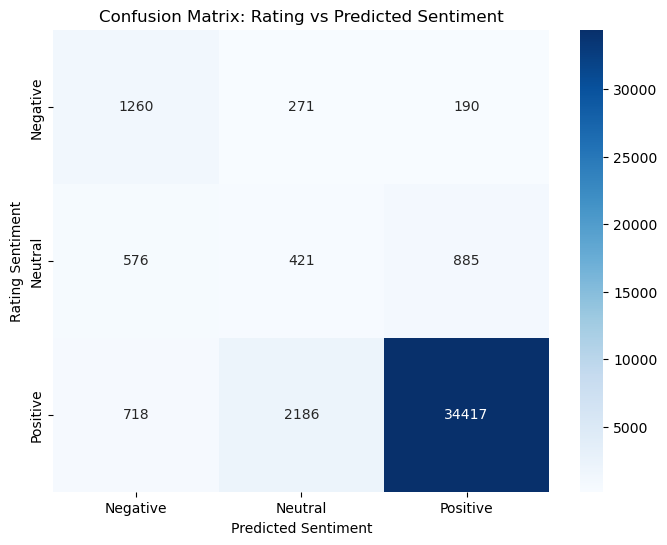


--- 3 Examples of Misclassifications ---
Original Text: Not easy for elderly users cease of ads that pop up....
Rating Sentiment: Positive | Predicted Sentiment: Negative

Original Text: A family member has vision problems. They had seen/used the Kindle of another family member - especially the ability to scale text. This device will make it possible to read, which she has had extreme difficulty doing....
Rating Sentiment: Positive | Predicted Sentiment: Neutral

Original Text: I bought this because I was tired of watching Youtube and Twitch on my phone. Excellent display sound is decent-not great but you can always buy a speaker. The negatives are-it is definitely a fingerprint magnet, and the Spectrum TV app is AWFUL-the app works fine on my phone, but for some reason on this tablet it freezes and is unusable. All things considered, for 65 bucks it's hard to be beat....
Rating Sentiment: Positive | Predicted Sentiment: Negative



In [15]:

labels_order = ['Negative', 'Neutral', 'Positive']
print(classification_report(
    df_sample['rating_sentiment'],
    df_sample['predicted_sentiment'],
    labels=labels_order,
    zero_division=0
))

# Confusion Matrix
cm = confusion_matrix(df_sample['rating_sentiment'], df_sample['predicted_sentiment'], labels=labels_order)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order, yticklabels=labels_order)
plt.title('Confusion Matrix: Rating vs Predicted Sentiment')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Rating Sentiment')
plt.show()

# Extract and print 3 specific examples of misclassifications
# Visual inspection to check for human labeling errors vs model errors.
errors = df_sample[df_sample['rating_sentiment'] != df_sample['predicted_sentiment']]

print("\n--- 3 Examples of Misclassifications ---")
if not errors.empty:
    for idx, row in errors.head(3).iterrows():
        print(f"Original Text: {row['reviews.text'][:400]}...")
        print(f"Rating Sentiment: {row['rating_sentiment']} | Predicted Sentiment: {row['predicted_sentiment']}\n")
else:
    print("No misclassifications found in the current dataframe.")

# Generate Content for All Categories for Website
Looping through every unique meta-category to rank products, extract context, and generate formatted articles for the website.

> Execution time : 1min

In [16]:
import time

print("Starting content generation for all categories...")
print("=" * 80)

# Loop through every unique cluster/category in the dataframe
for category in df_sample['meta_category'].dropna().unique():
    
    # Filter dataframe for the current category
    cat_df = df_sample[df_sample['meta_category'] == category].copy()
    
    # Map sentiment to numerical scores for mathematical ranking
    sentiment_map = {'Positive': 1, 'Neutral': 0, 'Negative': -1}
    cat_df['sentiment_score'] = cat_df['predicted_sentiment'].map(sentiment_map)
    
    # Aggregate data by product name to get stats and context
    product_stats = cat_df.groupby('name').agg(
        review_count=('reviews.text', 'count'),
        avg_score=('sentiment_score', 'mean'),
        complaints=('reviews.text', lambda x: list(x[cat_df.loc[x.index, 'predicted_sentiment'] == 'Negative'])[:3])
    ).reset_index()
    
    # Sort products to find the absolute best and worst
    ranked_products = product_stats.sort_values(by=['avg_score', 'review_count'], ascending=[False, False])
    num_products = len(ranked_products)
    
    # Skip empty clusters
    if num_products == 0:
        continue
        
    # 1. Identify Top 3 and Worst
    top_3 = ranked_products.head(3)['name'].tolist()
    worst = ranked_products.tail(1)['name'].values[0] if num_products > 1 else "Not enough products to evaluate a worst option."
    
    # 2. Extract review context (complaints)
    all_complaints = []
    for complaints in ranked_products['complaints']:
        all_complaints.extend(complaints)
    
    # Keep a concise sample to prevent overwhelming the LLM prompt
    sample_complaints = all_complaints[:5]
    if not sample_complaints:
        sample_complaints = ["No major complaints found in this category."]
        
    # 3. Package data into the dictionary format expected by generate_blog_post
    category_data = {
        'top_3': top_3,
        'worst': worst,
        'complaints': sample_complaints
    }
    
    # Call the Generative AI function
    article = generate_blog_post(category_data)
    
    # 4. Print clearly separated by dashed lines for easy copy-pasting
    print(f"\nCATEGORY: {category}")
    print("-" * 80)
    print(f"TOP 3 PRODUCTS: {', '.join(top_3)}")
    print(f"WORST PRODUCT: {worst}")
    print("-" * 80)
    print(article)
    print("=" * 80)
    
    # Small delay to respect API rate limits (crucial when looping multiple requests)
    time.sleep(1)

Starting content generation for all categories...

CATEGORY: 4
--------------------------------------------------------------------------------
TOP 3 PRODUCTS: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Black, Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Tangerine - with Special Offers, Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Special Offers, Black
WORST PRODUCT: Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Black,,,
Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Tangerine - with Special Offers",
--------------------------------------------------------------------------------
### Top Tablets for the Budget-Conscious Consumer: A Review of the Fire HD Series

When it comes to budget tablets, the All-New Fire HD 8 Tablet, the Fire HD 8 Tablet with Alexa in Tangerine, and the Fire Tablet with a 7-inch display stand out as the top contenders. The All-New Fire HD 8 Tablet boasts an 8-inch HD display and a generous 16 GB of storage, making it 